# preamble

In [1]:
import matplotlib.pyplot as plt

from spectrum2d.spectrum import convWnum2Freq
%matplotlib inline
import numpy as np
np.set_printoptions(precision=4)

In [2]:
import sys
sys.path.append("/home/vlew/CQCParse")

In [3]:
from CQCParse.parsing import GaussianDataParser
from CQCParse.relay import DataVault

In [4]:
from wilson import spectrum
from wilson import rendering
from wilson import analysis

from wilson.utils import get_package_root

In [5]:
wilson_root = get_package_root()
# data_vault = DataVault(wilson_root+'/tests/test_database/mini_files_database.csv')
data_vault = DataVault('/mnt/c/Users/vle014/OneDrive - UiT Office 365/Documents/files_fram/files_database.csv')

dataframe_gaussian = data_vault.getting_files_DB("gaussian")
method_basis = dataframe_gaussian[(dataframe_gaussian['code'] == 'FORM') & (dataframe_gaussian['method'] != 'PBE0')][["code", "method", "basis_set"]]
tuples_method_basis = [(row['code'], row['method'], row['basis_set']) for index, row in method_basis.iterrows()]
tuples_method_basis

[('FORM', 'HF', 'cc_pVDZ'),
 ('FORM', 'HF', 'cc_pVDZ_VPT2'),
 ('FORM', 'HF', 'cc_pVTZ'),
 ('FORM', 'HF', 'cc_pVQZ'),
 ('FORM', 'HF', 'cc_pVQZ_VPT2'),
 ('FORM', 'HF', 'STO_3G'),
 ('FORM', 'HF', 'STO_3G_DVPT2'),
 ('FORM', 'HF', 'STO_3G_VPT2'),
 ('FORM', 'HF', 'STO_3G_GVPT2'),
 ('FORM', 'HF', 'STO_3G_GVPT2_Resonances'),
 ('FORM', 'HF', 'STO_3G_DVPT2_Resonances'),
 ('FORM', 'HF', 'STO_3G_GVPT2_NoCoriolis_really'),
 ('FORM', 'HF', 'STO_3G_GVPT2_NoCoriolis'),
 ('FORM', 'HF', 'STO_3G_GVPT2_lineqs_conv1'),
 ('FORM', 'HF', 'STO_3G_GVPT2_lineqs_conv2'),
 ('FORM', 'HF', 'STO_3G_GVPT2_lineqs_conv3'),
 ('FORM', 'HF', 'STO_3G_GVPT2_lineqs_conv4'),
 ('FORM', 'B3LYP', 'cc_pVDZ'),
 ('FORM', 'B3LYP', 'cc_pVTZ'),
 ('FORM', 'B3LYP', 'cc_pVQZ'),
 ('FORM', 'B3LYP', 'aug_cc_pVTZ')]

In [6]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0], [] # make a dictionary

regions = {1: ((1282., 1457., 10.), (2589., 3051., 10.)),
           6: ((500., 3150., 10.), (500., 6050., 10.))}

# template
settings_here = {'electrical': [0], 'mechanical': [],
                 'Gamma_rc': broad_factor_rc, 'region': 1,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e12, 'norm_min': 1e7,
                 'dynamic_range_n': 30}

region = 1
# omega1 = np.arange(*regions[region][0])
# omega2 = np.arange(*regions[region][1])
omega1 = [1164., 1175., 1186., 1314., 1324., 1334., 1362., 1372., 1382., 1776., 1786., 1796.]
omega2 = [1736., 1746., 1757., 1975., 1986., 1997., 2295., 2301., 2311., 2323., 2931., 2942., 2952., 3073., 3083., 3093.]

vibEL = False
datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), '')

# stuff

In [7]:
computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)

print(computedSpectrum.fundamentals)
print(sorted(list(computedSpectrum.fundamentals.values())))
print(sorted(list(computedSpectrum.fundamentals_harmonic.values())))
# computedSpectrum.fundamentals_harmonic.values()


Used vibrational energy levels are harmonic? - False
{'0': 3560.764, '1': 3014.192, '2': 2955.502, '3': 1786.815, '4': 1436.403, '5': 1372.251, '6': 1324.394, '7': 1164.166, '8': 975.352, '9': 840.892, '10': 578.825, '11': 424.861, '12': 2966.938, '13': 1438.853, '14': 1049.419, '15': 645.672, '16': 533.342, '17': 51.769}
[51.769, 424.861, 533.342, 578.825, 645.672, 840.892, 975.352, 1049.419, 1164.166, 1324.394, 1372.251, 1436.403, 1438.853, 1786.815, 2955.502, 2966.938, 3014.192, 3560.764]
[75.182, 424.945, 546.973, 586.481, 666.778, 858.703, 999.249, 1070.601, 1203.019, 1339.071, 1409.644, 1473.063, 1478.573, 1819.014, 3050.847, 3107.945, 3158.837, 3745.028]


In [8]:
region = settings_here['region']
Gamma_rc = settings_here['Gamma_rc']
# Gamma = convWnum2Freq(Gamma_rc)
# el_bool = settings_here['electrical']
# mech_bool = settings_here['mechanical']
computedSpectrum.setSpectrumSettings(Gamma_rc)
sec_hypol_data = 0
if settings_here['electrical']:
    electrical, Qab_contrib_dict = computedSpectrum.intensity_electrical()
    sec_hypol_data += electrical

if settings_here['mechanical']:
    mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical()
    # template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
    sec_hypol_data += mechall

a, b 0 0
elavrg[a, b] -3.078537719331412e-08 0 0
0/324 modes combinations -- 0.0%
a, b 0 1
elavrg[a, b] -1.7846968343321908e-10 0 1
a, b 0 2
elavrg[a, b] 2.5075239275154344e-09 0 2
a, b 0 3
elavrg[a, b] 1.4770424051599417e-09 0 3
a, b 0 4
elavrg[a, b] 3.687433765031299e-11 0 4
a, b 0 5
elavrg[a, b] -9.768094081305299e-11 0 5
a, b 0 6
elavrg[a, b] 2.1218855275950833e-10 0 6
a, b 0 7
elavrg[a, b] 2.0453626675524875e-13 0 7
a, b 0 8
elavrg[a, b] -4.366899848873571e-10 0 8
a, b 0 9
elavrg[a, b] -8.387476716933712e-10 0 9
a, b 0 10
elavrg[a, b] 2.9609431355621833e-10 0 10
a, b 0 11
elavrg[a, b] 9.627457616507307e-11 0 11
a, b 0 12
elavrg[a, b] 9.063351480918973e-11 0 12
a, b 0 13
elavrg[a, b] -2.521353804641483e-11 0 13
a, b 0 14
elavrg[a, b] -6.469929425365202e-12 0 14
a, b 0 15
elavrg[a, b] -1.6571711537607805e-10 0 15
a, b 0 16
elavrg[a, b] -2.074256816333793e-10 0 16
a, b 0 17
elavrg[a, b] 7.78159296354461e-12 0 17
a, b 1 0
elavrg[a, b] -1.0275917108575253e-10 1 0
a, b 1 1
elavrg[a, b] 

In [9]:
abs(sec_hypol_data) ** 2

array([[2.5651146751034827e+05, 1.5406078670610179e+05, 5.5640303517895372e+04, 1.1234051687609250e+05, 1.7539673790545217e+05, 2.1353579808895313e+05, 5.1232538278291788e+04, 8.0305682824128249e+04, 1.3276513120048284e+05, 4.0355126589075255e+04,
        2.6023977246511952e+05, 5.4192885036360566e+05, 2.7176311956310883e+05, 5.3302888978621622e+03, 4.8506338684617140e+03, 4.4602502597197072e+03],
       [3.7882761145790952e+04, 1.1916533927014221e+05, 7.9020916026943712e+04, 3.6789405204493618e+04, 6.3185746359549143e+04, 7.2944760666340182e+04, 1.2400863047041992e+04, 1.7046300770598154e+04, 3.3322097543876822e+04, 5.9375716248288576e+04,
        5.5782402125866327e+04, 1.4134699279689207e+05, 2.7029323574409657e+05, 3.0309792864869873e+03, 2.7042871076921965e+03, 2.4425468372578225e+03],
       [5.6154292575130603e+03, 1.3156454631636432e+04, 4.7369160712711389e+04, 1.1562357622628500e+04, 1.9395389924420706e+04, 3.1876299220656394e+04, 2.8589530917027560e+03, 3.7182755905788367e+03

In [10]:
np.max(abs(sec_hypol_data) ** 2)

541928.8503636057

In [11]:
convWnum2Freq(1230), convWnum2Freq(2230)

(0.0056042923610817716, 0.01016062761399378)


self.intensities.max()==np.max(self.intensities.flatten(), axis=0): True 6.4126e-09


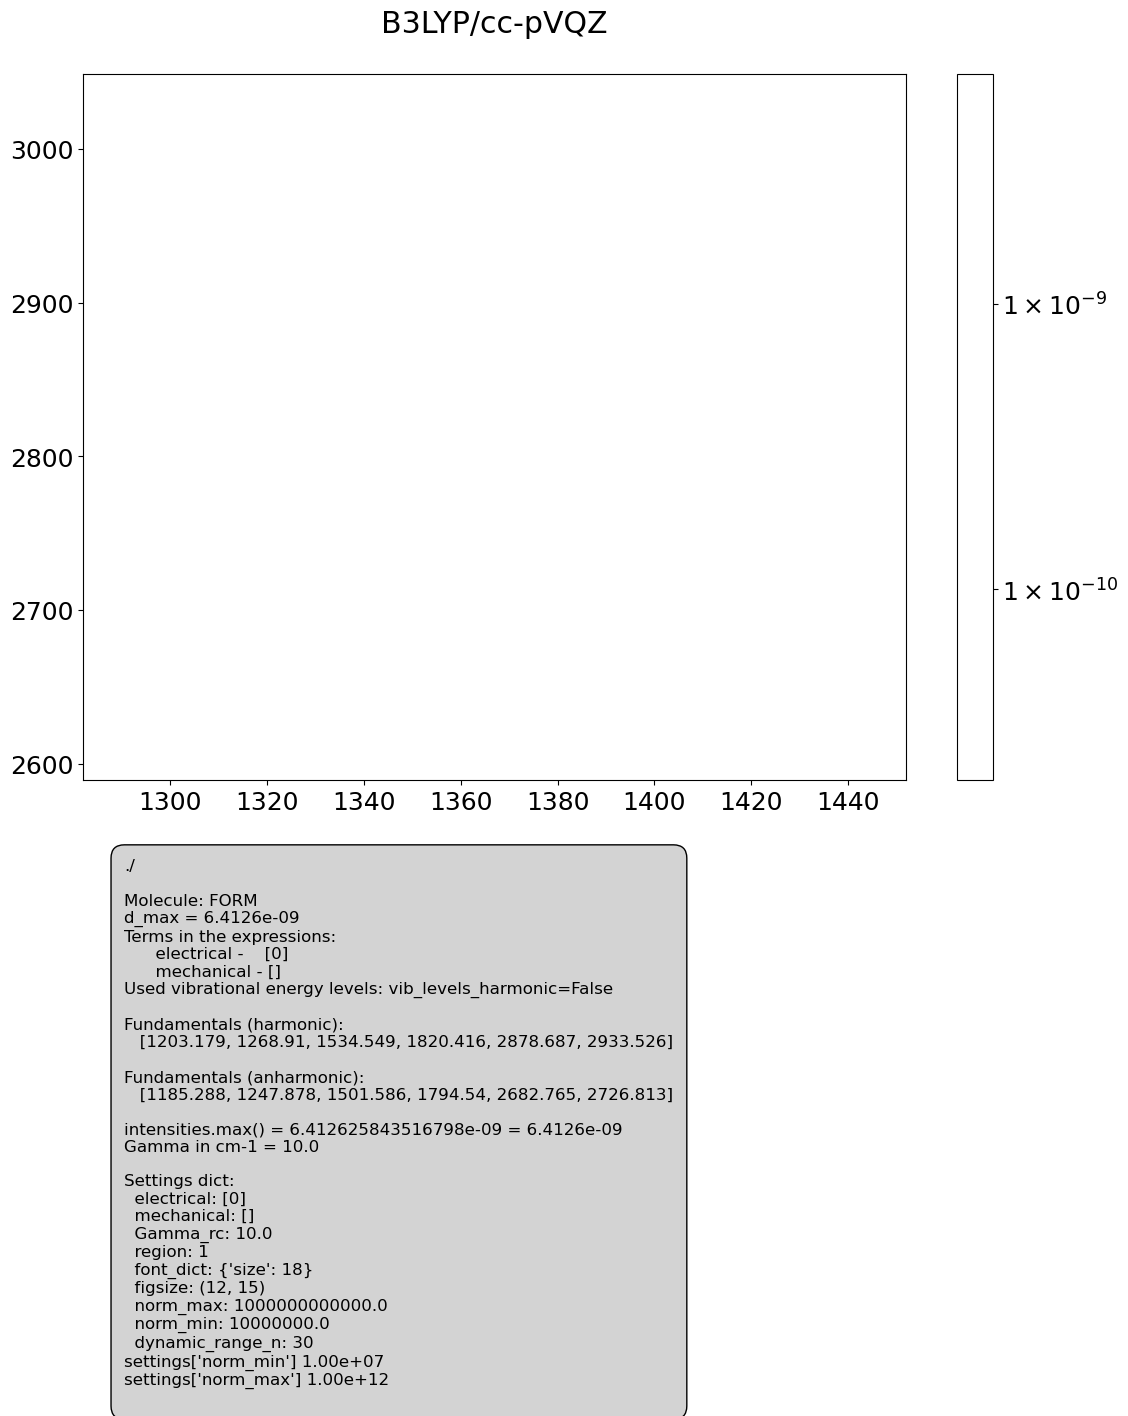

In [48]:
import os
directory='./'
other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

name = rendering.make_name(datain, vibEL, settings_here, other, directory)
artist = rendering.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
title_on_top, text_under_the_figure = rendering.make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
plt.show()

In [8]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0], [] # make a dictionary

regions = {1: ((1280., 3350., 10.), (2589., 6050., 10.)),
           6: ((500., 3150., 10.), (500., 6050., 10.))}

# template
settings_here = {'electrical': [0], 'mechanical': [],
                 'Gamma_rc': broad_factor_rc, 'region': 1,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e12, 'norm_min': 1e7,
                 'dynamic_range_n': 30}

# spectra_dict = {"software": [], "code": [], "method": [], "basis_set": [],
#                 "el+mech max": [], "el max": [], "mech max": []}

region = 1
omega1 = np.arange(*regions[region][0])
omega2 = np.arange(*regions[region][1])

vibEL = False
datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), wilson_root)

In [7]:
computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)

print(computedSpectrum.fundamentals)
print(sorted(list(computedSpectrum.fundamentals.values())))
print(sorted(list(computedSpectrum.fundamentals_harmonic.values())))
# computedSpectrum.fundamentals_harmonic.values()


Used vibrational energy levels are harmonic? - False
{'0': 2885.91, '1': 3185.566, '2': 3002.789, '3': 3282.474, '4': 2976.141, '5': 2791.954, '6': 3189.203, '7': 2906.359, '8': 1708.984, '9': 1649.419, '10': 1503.958, '11': 1477.665, '12': 1441.353, '13': 1506.717, '14': 1422.44, '15': 1420.881, '16': 1377.071, '17': 1360.974, '18': 1282.729, '19': 1276.773, '20': 1083.409, '21': 1045.114, '22': 1050.298, '23': 1008.669, '24': 955.851, '25': 915.571, '26': 888.182, '27': 884.448, '28': 624.688, '29': 612.197, '30': 627.269, '31': 582.801, '32': 494.362, '33': 433.742, '34': 160.048, '35': 155.843, '36': 131.03, '37': 78.344, '38': 12.878, '39': -54.702, '40': -127.992, '41': -136.12}
[-136.12, -127.992, -54.702, 12.878, 78.344, 131.03, 155.843, 160.048, 433.742, 494.362, 582.801, 612.197, 624.688, 627.269, 884.448, 888.182, 915.571, 955.851, 1008.669, 1045.114, 1050.298, 1083.409, 1276.773, 1282.729, 1360.974, 1377.071, 1420.881, 1422.44, 1441.353, 1477.665, 1503.958, 1506.717, 1649.

In [8]:
region = settings_here['region']
Gamma_rc = settings_here['Gamma_rc']
# el_bool = settings_here['electrical']
# mech_bool = settings_here['mechanical']

sec_hypol_data = 0
if settings_here['electrical']:
    electrical, Qab_contrib_dict = computedSpectrum.intensity_electrical(Gamma_rc)
    sec_hypol_data += electrical

if settings_here['mechanical']:
    mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma_rc)
    # template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
    sec_hypol_data += mechall

0/1764 modes combinations -- 0.0%
100/1764 modes combinations -- 5.668934240362812%
200/1764 modes combinations -- 11.337868480725623%
300/1764 modes combinations -- 17.006802721088434%
400/1764 modes combinations -- 22.675736961451246%
500/1764 modes combinations -- 28.34467120181406%
600/1764 modes combinations -- 34.01360544217687%
700/1764 modes combinations -- 39.682539682539684%
800/1764 modes combinations -- 45.35147392290249%
900/1764 modes combinations -- 51.02040816326531%
1000/1764 modes combinations -- 56.68934240362812%
1100/1764 modes combinations -- 62.358276643990926%
1200/1764 modes combinations -- 68.02721088435374%
1300/1764 modes combinations -- 73.69614512471655%
1400/1764 modes combinations -- 79.36507936507937%
1500/1764 modes combinations -- 85.03401360544218%
1600/1764 modes combinations -- 90.70294784580499%
1700/1764 modes combinations -- 96.3718820861678%
Execution time -| electrical: 17.055416584014893 seconds
Electrical anharmonicities are calculated


In [24]:
np.max(abs(sec_hypol_data) ** 2)

7.339657269721726e-06


self.intensities.max()==np.max(self.intensities.flatten(), axis=0): True 7.3397e-06


/home/vlew/Wilson/wilson/rendering/matplotlib_img.py:74: UserWarning: Log scale: values of z <= 0 have been masked
  cont = plt.contourf(self.X, self.Y, self.intensities,


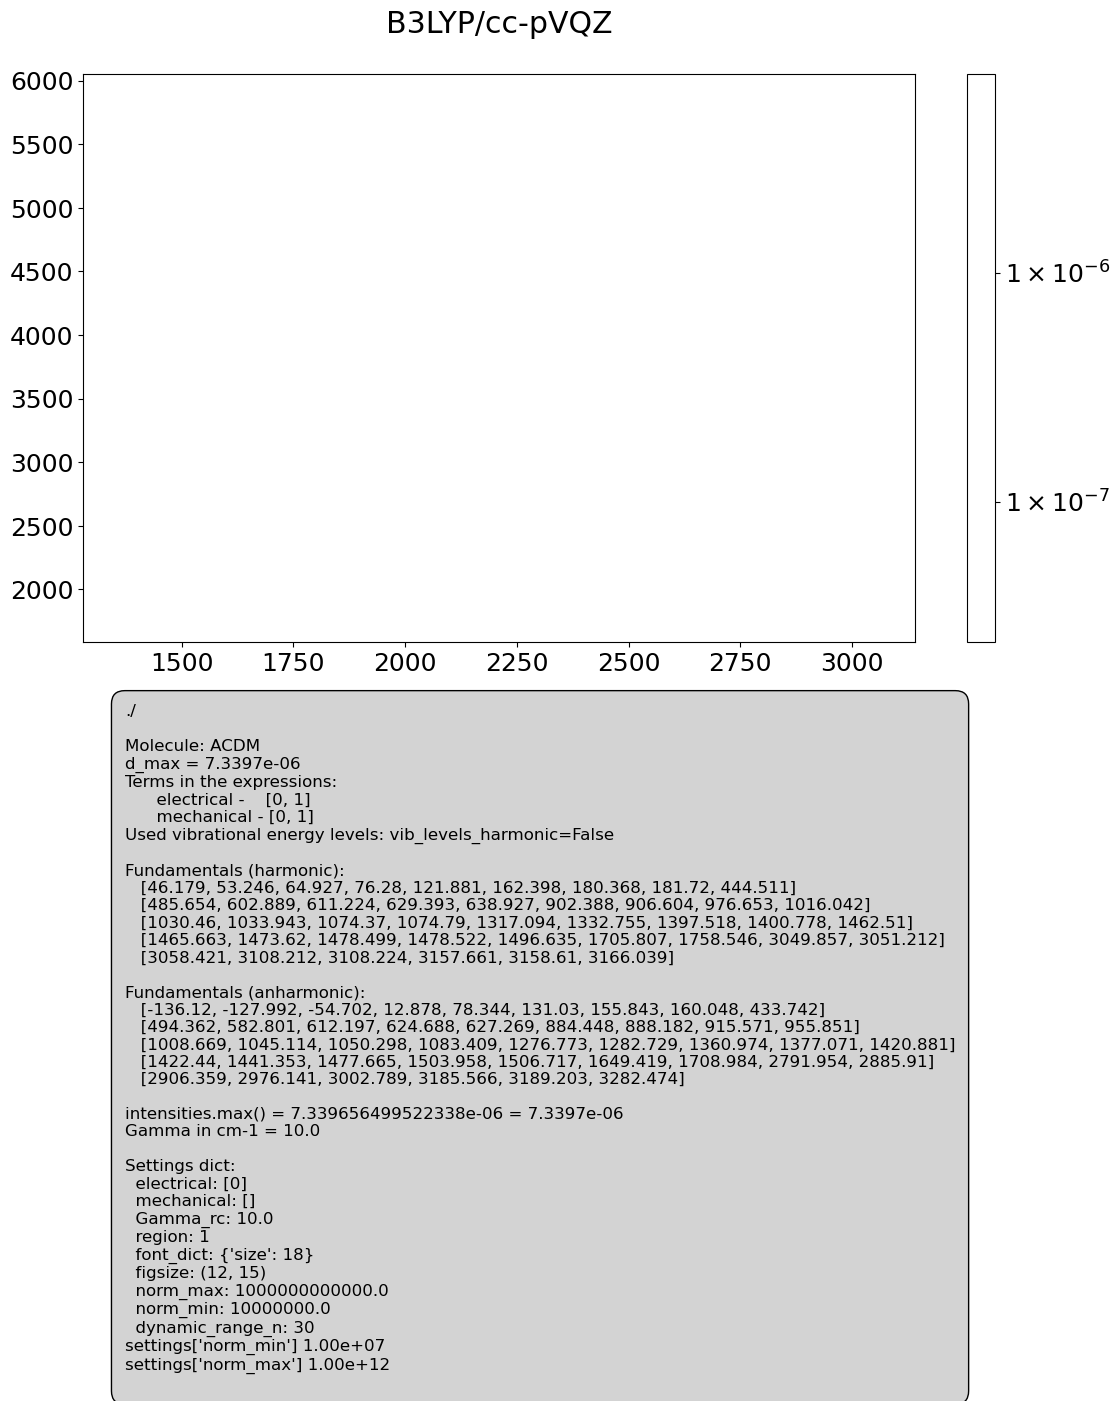

In [17]:
import os
directory='./'
other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

name = rendering.make_name(datain, vibEL, settings_here, other, directory)
artist = rendering.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
title_on_top, text_under_the_figure = rendering.make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
plt.show()

# Resonances

In [24]:
import pandas as pd
def plot1Fig_mplt(datain, settings_here, contrib_choice, directory='./', vibEL=False, exclude_modes_list=None):
    if exclude_modes_list is None:
        exclude_modes_list = []

    settings_here['electrical'] = contrib_choice[0]
    settings_here['mechanical'] = contrib_choice[1]

    region = settings_here['region']
    Gamma_rc = settings_here['Gamma_rc']

    omega1 = np.arange(*regions[region][0])
    omega2 = np.arange(*regions[region][1])

    computedSpectrum = spectrum.SpectrumEVV(input_data_info=datain, vib_levels_harmonic=vibEL)
    computedSpectrum.addTerms(*terms_selection)
    computedSpectrum.add_spectrum_grid(omega1, omega2)
    computedSpectrum.exclude_modes(exclude_modes_list)

    Gamma = spectrum.convWnum2Freq(Gamma_rc)

    sec_hypol_data = 0
    if settings_here['electrical']:
        el_gamma, Qab_contrib_dict = computedSpectrum.intensity_electrical(Gamma)
        sec_hypol_data += el_gamma

    if settings_here['mechanical']:
        mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma)
        template_array = np.full(mechall.shape, -0. + 0.j, dtype=complex)
        sec_hypol_data += mechall

    name = rendering.make_name(datain, vibEL, settings_here, other, directory)
    artist = rendering.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
    title_on_top, text_under_the_figure = rendering.make_texts4fig(datain, computedSpectrum, artist, settings_here,
                                                                   other, directory)
    fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                  text_under_the_figure=text_under_the_figure, diagonal=False, to_save=False)
    plt.show()


def analyse_mechanical_resonances(dataframe_mech_resonances):
    """Mechanical anharm resonances"""
    frames = []

    for dfMech in dataframe_mech_resonances:
        # how many resonances there could be - depends on 
        # the number of combinations of a,b,c - combinations_number = Nmodes**3
        # print the expressions for resonances of this term
        print('Resonances:', dfMech['res1'].iloc[0], '\nFormula:', dfMech['res2'].iloc[0], '\n')

        if rec_cm:
            # filters: non-zero F_abc; within the window selected above
            dfMech = dfMech[(dfMech['F_abc'] != 0.) & (dfMech['ω_2'] > dfMech['ω_1'])
                            & (dfMech['avrg_g'] != 0.)
                # & (abs(dfMech['ω_2']) > omega2[0]) & 
                            ].copy()
        else:
            dfMech = dfMech[(dfMech['F_abc'] != 0.) & (dfMech['ω_2'] > dfMech['ω_1'])
                            & (dfMech['avrg_g'] != 0.)
                # & (abs(dfMech['ω_2']) > spectrum.rec_cm2rec_s(omega2[0])) & 
                            ].copy()

        Gamma = spectrum.convWnum2Freq(settings_here['Gamma_rc'])

        # adding a column for the sum term in product
        if rec_cm:
            dfMech['SoF'] = spectrum.convWnum2Freq(dfMech['FR1'] + dfMech['FR2']) / spectrum.convWnum2Freq(
                dfMech['FR1']) / spectrum.convWnum2Freq(dfMech['FR2'])
            dfMech['Fermi'] = 1. / spectrum.convWnum2Freq(dfMech['FR1']) / spectrum.convWnum2Freq(dfMech['FR2'])
            dfMech['abs Fermi'] = abs(1. / spectrum.convWnum2Freq(dfMech['FR1']) / spectrum.convWnum2Freq(dfMech['FR2']))
            dfMech['DoR'] = np.real(dfMech['SoF'] * (1. / (- 1j * Gamma) / (- 1j * Gamma)))
        else:
            # sum of fermi terms
            dfMech['SoF'] = (dfMech['FR1'] + dfMech['FR2']) / dfMech['FR1'] / dfMech['FR2']
            dfMech['Fermi'] = 1. / dfMech['FR1'] / dfMech['FR2']
            dfMech['abs Fermi'] = abs(1. / dfMech['FR1'] / dfMech['FR2'])
            # product of resonance terms
            dfMech['DoR'] = np.real(dfMech['SoF'] * (1. / (- 1j * Gamma) / (- 1j * Gamma)))
        # dfMech['resonances'] is confirmed now, so the rest should be okay too; now confirmed!
        dfMech['gamma_mn'] = dfMech['avrg_g'] * dfMech['F_abc'] * dfMech['DoR'] / computedSpectrum.prefac_3d.T[
            dfMech['a'], dfMech['b'], dfMech['c']] * (-1.) / 48.
        dd = []
        for idx, row in dfMech.iterrows():
            d = {abs(row['avrg_g']): 'avrg_g',
                 abs(row['F_abc']): 'F_abc',
                 abs(row['DoR']) / abs(row['SoF']): 'res',
                 abs(row['SoF']): 'SoF',
                 computedSpectrum.prefac_3d.T[row['a'], row['b'], row['c']]: 'pref'}
            dd.append(d[max([abs(row['avrg_g']), abs(row['F_abc']), abs(row['DoR']) / abs(row['SoF']), abs(row['SoF']),
                             computedSpectrum.prefac_3d.T[row['a'], row['b'], row['c']]])])
        dfMech['distribution'] = dd
        frames.append(dfMech)

    result = pd.concat(frames)
    result['abs'] = abs(result['gamma_mn']) ** 2

    df = result[
        ['ii', 'a', 'b', 'c', 'ω_1', 'ω_2', 'FR1', 'FR2', 'SoF', 'distribution', 'DoR', 'avrg_g', 'F_abc', 'gamma_mn',
         'abs']]
    formatted_df = df.copy()
    formatted_df['SoF'] = df['SoF'].map('{:.1f}'.format)
    formatted_df['FR1'] = df['FR1'].map('{:.1f}'.format)
    formatted_df['FR2'] = df['FR2'].map('{:.1f}'.format)
    formatted_df['DoR'] = df['DoR'].map('{:.1e}'.format)
    formatted_df['avrg_g'] = df['avrg_g'].map('{:.1e}'.format)
    formatted_df['F_abc'] = df['F_abc'].map('{:.1e}'.format)

    return formatted_df


def analyse_electrical_resonances(dataframe_electric_resonances):
    """
    Takes dataframe_electric_resonances - output from analysis.get_resonances_DF, a list of dataframes
    with columns: ['ii', 'res', 'a', 'b', 'ω_a', 'ω_b', 'ω_2-ω_1', 'ω_1', 'ω_2', 'avrg_g']
    Returns a dataframe with columns:
                  ['ii', 'res', 'a', 'b', 'ω_1', 'ω_2', 'distribution', 'DoR', 'avrg_g', 'gamma_mn', 'abs']
    """
    frames = []

    for dfElectric in dataframe_electric_resonances:
        # how many resonances there could be - depends on the number of combinations of a,b - combinations_number = Nmodes**2
        # print the expressions for resonances of this term
        print('Resonance:', dfElectric['res'].iloc[0], '\n')

        if rec_cm:
            # filters: non-zero F_abc; within the window selected above
            dfElectric = dfElectric[(dfElectric['ω_2'] > dfElectric['ω_1'])
                                    & (dfElectric['avrg_g'] != 0.)
                # & (abs(dfElectric['ω_2']) > omega2[0]) & 
                                    ].copy()
        else:
            dfElectric = dfElectric[(dfElectric['ω_2'] > dfElectric['ω_1'])
                                    & (dfElectric['avrg_g'] != 0.)
                # & (abs(dfElectric['ω_2']) > spectrum.rec_cm2rec_s(omega2[0])) & 
                                    ].copy()

        Gamma = spectrum.convWnum2Freq(settings_here['Gamma_rc'])

        # adding a column for the sum term in product
        if rec_cm:
            dfElectric['DoR'] = 1. / (- 1j * Gamma) / (- 1j * Gamma)
        else:
            dfElectric['SoF'] = (dfElectric['FR1'] + dfElectric['FR2']) / dfElectric['FR1'] / dfElectric['FR2']
            dfElectric['Fermi'] = 1. / dfElectric['FR1'] / dfElectric['FR2']
            dfElectric['abs Fermi'] = abs(1. / dfElectric['FR1'] / dfElectric['FR2'])
            dfElectric['DoR'] = np.real(dfElectric['SoF'] * (1. / (- 1j * Gamma) / (- 1j * Gamma)))
        # dfElectric['resonances'] is not yet confirmed
        dfElectric['gamma_mn'] = dfElectric['avrg_g'] * dfElectric['DoR'] / computedSpectrum.prefac_2d.T[
            dfElectric['a'], dfElectric['b']] / 24.
        dd = []
        for idx, row in dfElectric.iterrows():
            d = {abs(row['avrg_g']): 'avrg_g',
                 # abs(row['DoR'])/abs(row['SoF']): 'res', 
                 computedSpectrum.prefac_2d.T[row['a'], row['b']]: 'pref'}
            dd.append(d[max([abs(row['avrg_g']), computedSpectrum.prefac_2d.T[row['a'], row['b']]])])
        dfElectric['distribution'] = dd
        frames.append(dfElectric)

    result = pd.concat(frames)
    result['abs'] = abs(result['gamma_mn']) ** 2

    df = result[['ii', 'res', 'a', 'b', 'ω_1', 'ω_2', 'distribution', 'DoR', 'avrg_g', 'gamma_mn', 'abs']]
    formatted_df = df.copy()
    formatted_df['DoR'] = df['DoR'].map('{:.1e}'.format)
    formatted_df['avrg_g'] = df['avrg_g'].map('{:.1e}'.format)

    return formatted_df


def compile_df4plot(formatted_df2):
    """
    Should work for either electrical or mechanical
    Take a df from analyse_electrical_resonances with columns:
    ['ii', 'res', 'a', 'b', 'ω_1', 'ω_2', 'distribution', 'DoR', 'avrg_g', 'gamma_mn', 'abs']
    Return a df for plotly plot with columns: ['ω_1', 'ω_2', 'gamma_mn', 'ii', 'term', 'final', 'ab_tuples']
    """
    dict_agg = {'gamma_mn': 'sum', 'a': lambda x: list(x), 'b': lambda x: list(x)}

    if 'c' in formatted_df2.columns:
        dict_agg['c'] = lambda x: list(x)
        dict_agg['ii'] = lambda x: list(x)
    else:
        dict_agg['ii'] = lambda x: list(x)
        
    # smaller dataframe
    result_later = (
        formatted_df2
        .groupby(['ω_1', 'ω_2'])
        .agg(dict_agg).reset_index() )
    
    result_later['term'] = result_later['ii'].apply(lambda x: ', '.join(map(str, x)))
    # columns now: ['ω_1', 'ω_2', 'gamma_mn', 'a', 'b', ('c'), 'ii', 'term']
    result_later['final'] = abs(result_later['gamma_mn']) ** 2
    result_later['ω_1'] = result_later['ω_1'].map('{:.3f}'.format)
    result_later['ω_2'] = result_later['ω_2'].map('{:.3f}'.format)
    
    if 'c' in formatted_df2.columns:
        result_later['abc_tuples'] = result_later.apply(lambda row: str(list(zip(row['a'], row['b'], row['c']))), axis=1)
        result_later = result_later.drop(columns=['a', 'b', 'c'])
        # columns now: ['ω_1', 'ω_2', 'gamma_mn', 'ii', 'term', 'final', 'abc_tuples']
        
    else:
        result_later['ab_tuples'] = result_later.apply(lambda row: str(list(zip(row['a'], row['b']))), axis=1)
        result_later = result_later.drop(columns=['a', 'b'])
        # columns now: ['ω_1', 'ω_2', 'gamma_mn', 'ii', 'term', 'final', 'ab_tuples']
    
    max_intensity = max(result_later['final'])
    power = float(np.log10(max_intensity)).__floor__()
    
    # formatted_df['final'] = np.log10(result_later['final']) if result_later[result_later['final']]>1e4 else 0.
    # formatted_df1['final'] = formatted_df1['final'].apply(lambda x: 0 if x < 1e4 else np.log(x))

    return result_later, power


def plot1Fig_plotly(result_later, figtitle):
    """
    Can plot either electrical or mechanical
    """
    formatted_df1 = result_later.copy()
    # print(power, formatted_df1['final'].max())
    # formatted_df['final'] = np.log10(result_later['final']) if result_later[result_later['final']]>1e4 else 0.
    # formatted_df1['final'] = formatted_df1['final'].apply(lambda x: 0 if x < 1e4 else np.log(x))
    if 'ab_tuples' in formatted_df1.columns:
        ab_c_name = 'ab_tuples' 
    else:
        ab_c_name = 'abc_tuples'
        
    symbol_dict = {'0': 'x', '1': 'diamond', '2': 'square', '3': 'triangle', '4': 'circle', '5': 'star'}
    
    import plotly.io as pio
    import plotly.express as px
    
    pio.templates.default = "ggplot2"
    fig = px.scatter(formatted_df1[(formatted_df1['final'] > 1e5)
                         # &(formatted_df['final']<1e8)
                     ],
                     x='ω_1',
                     y='ω_2',
                     color='final',
                     symbol="term",
                     color_continuous_scale='viridis',
                     title=figtitle,
                     width=1300, height=800,
                     hover_data={'final': ':.4e', f'{ab_c_name}': True,  #'a': True, 'b': True, 'c': True
                                 },
                     symbol_map=symbol_dict,
                     range_color=(5e4, 0.4e7))
    
    fig.update_layout(
        xaxis_title='ω_1',
        yaxis_title='ω_2',
        coloraxis_colorbar=dict(title='final'),
        plot_bgcolor='aliceblue'
    )
    
    fig.update_layout(
        legend=dict(
            x=0.5,
            y=-0.1,
            xanchor='center',
            yanchor='top',
            orientation='h',
            bgcolor="LightBlue"
        ),)
    
    fig.update_xaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
    fig.update_yaxes(showline=True, linewidth=1, linecolor='black', mirror=True)
    
    fig.update_xaxes(showgrid=True, gridwidth=0.4, gridcolor='LightPink')
    fig.update_yaxes(showgrid=True, gridwidth=0.4, gridcolor='LightPink')
    fig.update_coloraxes(colorbar_tickformat='.2e'.format())
    fig.update_layout(autotypenumbers='convert types')
    
    fig.show()


In [27]:
terms_selection = [0, 1], []
# omega1 = [1164., 1175., 1186., 1314., 1324., 1334., 1362., 1372., 1382., 1776., 1786., 1796.]
# omega2 = [1736., 1746., 1757., 1975., 1986., 1997., 2295., 2301., 2311., 2323., 2931., 2942., 2952., 3073., 3083., 3093.]

datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), wilson_root)
vib_levels_harmonic = False
rec_cm = True
computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, 
                                        vib_levels_harmonic=vib_levels_harmonic)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)
# computedSpectrum.exclude_modes([34, 35, 36, 37, 38, 39, 40, 41])

dfs4terms_el, dfs4terms_mech = analysis.get_resonances_DF(computedSpectrum, rec_cm=rec_cm,
                                                          vib_levels_harmonic=vib_levels_harmonic)
formatted_df2 = analyse_electrical_resonances(dfs4terms_el)

result_later, power = compile_df4plot(formatted_df2)
figtitle = f'Acetic acid monomer: electrical {terms_selection[0]} anharmonicity contribution'

plot1Fig_plotly(result_later, figtitle)


Used vibrational energy levels are harmonic? - False
Resonance: a+b,a__zero,a 

Resonance: b,a__zero,a 



In [26]:
terms_selection = [], [0]

datain = data_vault.make_DatainputDict('gaussian', ('ACAC', 'B3LYP', 'cc_pVQZ'), wilson_root)
vib_levels_harmonic = False
rec_cm = True
computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, 
                                        vib_levels_harmonic=vib_levels_harmonic)
computedSpectrum.load_data(GaussianDataParser)
computedSpectrum.addTerms(*terms_selection)
# computedSpectrum.exclude_modes([34, 35, 36, 37, 38, 39, 40, 41])

dfs4terms_el, dfs4terms_mech = analysis.get_resonances_DF(computedSpectrum, rec_cm=rec_cm,
                                                          vib_levels_harmonic=vib_levels_harmonic)
formatted_df22 = analyse_mechanical_resonances(dfs4terms_mech)

result_later22, power = compile_df4plot(formatted_df22)
figtitle = f'Acetic acid monomer: mechanical {terms_selection[1]} anharmonicity contribution'
    
plot1Fig_plotly(result_later22, figtitle)


Used vibrational energy levels are harmonic? - False
Resonances: a+b,a__zero,a 
Formula: a+b+c,zero__c,a+b 

